# Multilayer Perceptron (MLP)

A Multilayer Perceptron (MLP) was used as an additional neural-network approach for 
sentiment classification. Unlike the LSTM model, which operates on sequences of words, 
the MLP uses the TF-IDF representation of the reviews as input features.

The MLP was evaluated using both balanced and imbalanced training datasets. Several 
network architectures were compared using the validation Macro F1 score, after which 
the best-performing architecture was evaluated on the test set.

In [2]:
import pickle
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

## Balanced Training

In [3]:
with open("prepared_data.pkl", "rb") as f:
    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        vectorizer,
    ) = pickle.load(f)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

Training: (39999, 10000)
Validation: (5000, 10000)
Test: (5000, 10000)

Training class distribution:
Score
good       13333
bad        13333
neutral    13333
Name: count, dtype: int64


In [4]:
label_map = {
    "bad": 0,
    "neutral": 1,
    "good": 2
}

y_train_mlp = pd.Series(y_train).map(label_map)
y_val_mlp = pd.Series(y_val).map(label_map)
y_test_mlp = pd.Series(y_test).map(label_map)

print(y_train_mlp.value_counts())

Score
2    13333
0    13333
1    13333
Name: count, dtype: int64


### Baseline Model

In [5]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=20,
    batch_size=128,
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3
)

mlp.fit(X_train, y_train_mlp)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,128
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,20
,shuffle,True
,random_state,42


In [6]:
y_val_pred = mlp.predict(X_val)

print("Accuracy:", accuracy_score(y_val_mlp, y_val_pred))
print("Macro F1:", f1_score(y_val_mlp, y_val_pred, average="macro"))
print("Weighted F1:", f1_score(y_val_mlp, y_val_pred, average="weighted"))

print("\nClassification report:")
print(classification_report(
    y_val_mlp,
    y_val_pred,
    target_names=["bad", "neutral", "good"]
))

Accuracy: 0.8544
Macro F1: 0.716328208812365
Weighted F1: 0.8731811587414148

Classification report:
              precision    recall  f1-score   support

         bad       0.67      0.83      0.74       484
     neutral       0.36      0.75      0.48       347
        good       0.98      0.87      0.92      4169

    accuracy                           0.85      5000
   macro avg       0.67      0.82      0.72      5000
weighted avg       0.91      0.85      0.87      5000



In [7]:
y_test_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test_mlp, y_test_pred))
print("Macro F1:", f1_score(y_test_mlp, y_test_pred, average="macro"))
print("Weighted F1:", f1_score(y_test_mlp, y_test_pred, average="weighted"))

print("\nClassification report:")
print(classification_report(
    y_test_mlp,
    y_test_pred,
    target_names=["bad", "neutral", "good"]
))

Accuracy: 0.8634
Macro F1: 0.725364654038433
Weighted F1: 0.8800665925004855

Classification report:
              precision    recall  f1-score   support

         bad       0.69      0.84      0.76       484
     neutral       0.37      0.73      0.49       347
        good       0.98      0.88      0.93      4169

    accuracy                           0.86      5000
   macro avg       0.68      0.82      0.73      5000
weighted avg       0.91      0.86      0.88      5000



### Architecture Comparison

In [8]:
architectures = [
    (50,),
    (100,),
    (200,),
    (100, 50)
]

mlp_results = []

for architecture in architectures:
    print(f"Training MLP {architecture}...")

    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        max_iter=20,
        batch_size=128,
        learning_rate_init=0.001,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=3
    )

    model.fit(X_train, y_train_mlp)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val_mlp, y_pred)
    macro_f1 = f1_score(y_val_mlp, y_pred, average="macro")
    weighted_f1 = f1_score(y_val_mlp, y_pred, average="weighted")

    mlp_results.append({
        "Architecture": architecture,
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

mlp_results_df = pd.DataFrame(mlp_results)
mlp_results_df

Training MLP (50,)...
Training MLP (100,)...
Training MLP (200,)...
Training MLP (100, 50)...


,Architecture,Accuracy,Macro F1,Weighted F1
0,"(50,)",0.8600,0.721882,0.876986
1,"(100,)",0.8544,0.716328,0.873181
2,"(200,)",0.8542,0.716504,0.873648
3,"(100, 50)",0.8476,0.710073,0.867877


### Final Model

In [9]:
best_mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=20,
    batch_size=128,
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3
)

best_mlp.fit(X_train, y_train_mlp)

print("Number of iterations:", best_mlp.n_iter_)

Number of iterations: 6


In [10]:
y_test_pred_mlp = best_mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test_mlp, y_test_pred_mlp))
print("Macro F1:", f1_score(y_test_mlp, y_test_pred_mlp, average="macro"))
print("Weighted F1:", f1_score(y_test_mlp, y_test_pred_mlp, average="weighted"))

print("\nClassification report:")
print(classification_report(
    y_test_mlp,
    y_test_pred_mlp,
    target_names=["bad", "neutral", "good"]
))

Accuracy: 0.8686
Macro F1: 0.7337808919815303
Weighted F1: 0.8833611472924431

Classification report:
              precision    recall  f1-score   support

         bad       0.68      0.86      0.76       484
     neutral       0.40      0.74      0.52       347
        good       0.98      0.88      0.93      4169

    accuracy                           0.87      5000
   macro avg       0.69      0.83      0.73      5000
weighted avg       0.91      0.87      0.88      5000



### Confusion Matrix

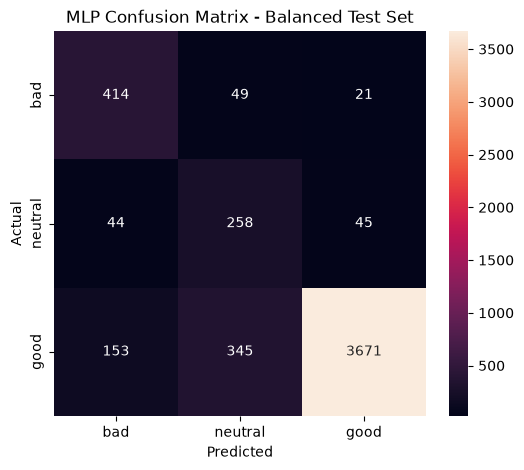

In [11]:
cm = confusion_matrix(y_test_mlp, y_test_pred_mlp)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["bad", "neutral", "good"],
    yticklabels=["bad", "neutral", "good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix - Balanced Training")
plt.show()

In [12]:
mlp_results_df

,Architecture,Accuracy,Macro F1,Weighted F1
0,"(50,)",0.8600,0.721882,0.876986
1,"(100,)",0.8544,0.716328,0.873181
2,"(200,)",0.8542,0.716504,0.873648
3,"(100, 50)",0.8476,0.710073,0.867877


## MLP - Balanced Training

A Multilayer Perceptron (MLP) was trained using the TF-IDF representation of the reviews. 
The baseline model used one hidden layer with 100 neurons. Several network architectures 
were then compared using the validation Macro F1 score.

The tested architectures were `(50,)`, `(100,)`, `(200,)`, and `(100, 50)`. 
The best validation result was obtained with a single hidden layer containing 50 neurons.

The final MLP model achieved the following results on the test set:

- Accuracy: **0.8686**
- Macro F1: **0.7338**
- Weighted F1: **0.8834**

The model achieved an F1 score of **0.76** for the `bad` class, **0.52** for the 
`neutral` class, and **0.93** for the `good` class. The `neutral` class remained the 
most difficult to classify, while the `good` class was recognized most successfully.

Overall, the MLP achieved competitive performance compared with the other classical 
machine learning models and provides an additional neural-network approach based on 
TF-IDF features.

## Imbalanced Training

In [13]:
with open("prepared_data_imbalanced.pkl", "rb") as f:
    (
        X_train_imb,
        y_train_imb,
        X_val_imb,
        y_val_imb,
        X_test_imb,
        y_test_imb,
        vectorizer_imb,
    ) = pickle.load(f)

print("Training:", X_train_imb.shape)
print("Validation:", X_val_imb.shape)
print("Test:", X_test_imb.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train_imb).value_counts())

Training: (40000, 10000)
Validation: (5000, 10000)
Test: (5000, 10000)

Training class distribution:
Score
good       33353
bad         3869
neutral     2778
Name: count, dtype: int64


In [14]:
y_train_imb_mlp = pd.Series(y_train_imb).map(label_map)
y_val_imb_mlp = pd.Series(y_val_imb).map(label_map)
y_test_imb_mlp = pd.Series(y_test_imb).map(label_map)

print(y_train_imb_mlp.value_counts())

Score
2    33353
0     3869
1     2778
Name: count, dtype: int64


In [18]:
mlp_imb = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=20,
    batch_size=128,
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3
)

mlp_imb.fit(X_train_imb, y_train_imb_mlp)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,128
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,20
,shuffle,True
,random_state,42


In [19]:
y_val_pred_imb = mlp_imb.predict(X_val_imb)

print("Accuracy:", accuracy_score(y_val_imb_mlp, y_val_pred_imb))
print("Macro F1:", f1_score(y_val_imb_mlp, y_val_pred_imb, average="macro"))
print("Weighted F1:", f1_score(y_val_imb_mlp, y_val_pred_imb, average="weighted"))

print("\nClassification report:")
print(classification_report(
    y_val_imb_mlp,
    y_val_pred_imb,
    target_names=["bad", "neutral", "good"]
))

Accuracy: 0.9162
Macro F1: 0.7465698101611599
Weighted F1: 0.9113585579694613

Classification report:
              precision    recall  f1-score   support

         bad       0.78      0.74      0.76       484
     neutral       0.62      0.44      0.52       347
        good       0.95      0.98      0.96      4169

    accuracy                           0.92      5000
   macro avg       0.78      0.72      0.75      5000
weighted avg       0.91      0.92      0.91      5000



### Architecture Comparison

In [20]:
mlp_imb_results = []

for architecture in architectures:
    print(f"Training MLP {architecture}...")

    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        max_iter=20,
        batch_size=128,
        learning_rate_init=0.001,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=3
    )

    model.fit(X_train_imb, y_train_imb_mlp)

    y_pred = model.predict(X_val_imb)

    accuracy = accuracy_score(y_val_imb_mlp, y_pred)
    macro_f1 = f1_score(y_val_imb_mlp, y_pred, average="macro")
    weighted_f1 = f1_score(y_val_imb_mlp, y_pred, average="weighted")

    mlp_imb_results.append({
        "Architecture": architecture,
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

mlp_imb_results_df = pd.DataFrame(mlp_imb_results)
mlp_imb_results_df

Training MLP (50,)...
Training MLP (100,)...
Training MLP (200,)...
Training MLP (100, 50)...


,Architecture,Accuracy,Macro F1,Weighted F1
0,"(50,)",0.9196,0.752046,0.913763
1,"(100,)",0.9162,0.746570,0.911359
2,"(200,)",0.9174,0.750479,0.912061
3,"(100, 50)",0.9138,0.750844,0.911421


### Final Model


In [21]:
best_mlp_imb = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=20,
    batch_size=128,
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3
)

best_mlp_imb.fit(X_train_imb, y_train_imb_mlp)

print("Number of iterations:", best_mlp_imb.n_iter_)

Number of iterations: 8


In [22]:
y_pred_imb = best_mlp_imb.predict(X_test_imb)

print("Imbalanced Test")
print("Accuracy:", accuracy_score(y_test_imb_mlp, y_pred_imb))
print("Macro F1:", f1_score(y_test_imb_mlp, y_pred_imb, average="macro"))
print("Weighted F1:", f1_score(y_test_imb_mlp, y_pred_imb, average="weighted"))

print("\nClassification Report:")
print(
    classification_report(
        y_test_imb_mlp,
        y_pred_imb,
        target_names=["bad", "neutral", "good"]
    )
)

Imbalanced Test
Accuracy: 0.9222
Macro F1: 0.7592145137386755
Weighted F1: 0.9156625144418035

Classification Report:
              precision    recall  f1-score   support

         bad       0.81      0.76      0.78       484
     neutral       0.71      0.43      0.53       347
        good       0.94      0.98      0.96      4169

    accuracy                           0.92      5000
   macro avg       0.82      0.72      0.76      5000
weighted avg       0.91      0.92      0.92      5000



### Confusion Matrix

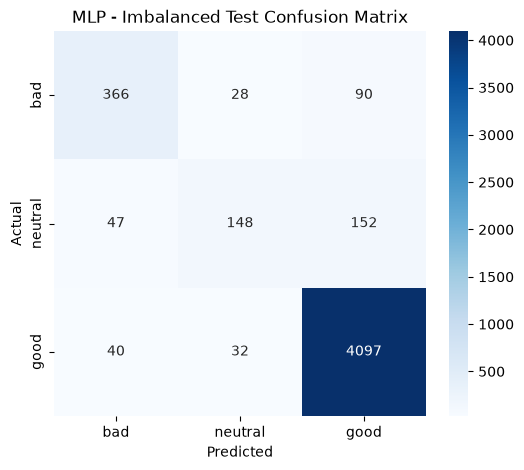

In [23]:
cm_imb = confusion_matrix(y_test_imb_mlp, y_pred_imb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_imb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["bad", "neutral", "good"],
    yticklabels=["bad", "neutral", "good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP - Imbalanced Test Confusion Matrix")
plt.show()

## MLP - Imbalanced Training
A Multilayer Perceptron (MLP) was trained using the TF-IDF representation of the reviews. 
The baseline model used one hidden layer with 100 neurons. Several network architectures 
were then compared using the validation Macro F1 score.

The tested architectures were `(50,)`, `(100,)`, `(200,)`, and `(100, 50)`. 
The best validation result was obtained with a single hidden layer containing 50 neurons.

The final MLP model achieved the following results on the test set:

- Accuracy: **0.9222**
- Macro F1: **0.7592**
- Weighted F1: **0.9157**

The model achieved an F1 score of **0.78** for the `bad` class, **0.53** for the 
`neutral` class, and **0.96** for the `good` class. The `neutral` class remained the 
most difficult to classify, while the `good` class was recognized most successfully.

Overall, the MLP achieved strong performance on the imbalanced dataset. The model performed particularly well on the dominant `good` class, while classification of the `neutral` class remained more challenging.

## MLP – Balanced vs Imbalanced

The MLP achieved better performance when trained on the imbalanced dataset. The test 
Accuracy increased from **0.8686** to **0.9222**, while Macro F1 increased from **0.7338** 
to **0.7592**. Weighted F1 also improved from **0.8834** to **0.9157**.

| Training Setup | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| Balanced | 0.8686 | 0.7338 | 0.8834 |
| Imbalanced | **0.9222** | **0.7592** | **0.9157** |

The imbalanced model performed particularly well on the dominant `good` class, achieving 
an F1 score of **0.96**. However, the `neutral` class remained the most difficult to 
classify, with an F1 score of **0.53**.

Overall, the imbalanced MLP achieved higher performance on the test set, although its 
results are strongly influenced by the large number of `good` reviews.